In [1]:
import pandas as pd 
import numpy as np

df = pd.read_csv('dat_train1.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'dat_train1.csv'

In [ ]:
pd.to_datetime(df['event_timestamp'].head())

0   2021-11-04 14:11:15+00:00
1   2021-11-04 14:11:29+00:00
2   2021-11-04 14:12:10+00:00
3   2021-11-04 14:12:21+00:00
4   2021-11-04 14:12:24+00:00
Name: event_timestamp, dtype: datetime64[ns, UTC]

## Task 1

A **complete journey** would be one where the journey ends with an order shipped. This means that no matter how long a journey takes, as long as it ends with a shipping of an order, it would be considered a successful journey. An **failed journey** would be a journey that with the cut off date in mind, at least 60 days before that cut off date the journeys did not have any activity. An **incomplete journey** would be one where the last activity was within the last 60 days that didn't end with the shipping 

## Task 2 - Create training data for incomplete journeys

In [ ]:
df.shape

(54960961, 8)

In [ ]:
df = df.drop_duplicates(subset=['customer_id', 'account_id', 'event_name', 'event_timestamp']).copy()

In [ ]:
df.shape

(51848861, 8)

In [ ]:
df.head()

,customer_id,account_id,ed_id,event_name,event_timestamp,journey_steps_until_end,id,sep
0,15849251,383997507,4,browse_products,2021-11-04T14:11:15Z,1,15849251 383997507,-
1,15849251,383997507,4,browse_products,2021-11-04T14:11:29Z,2,15849251 383997507,-
2,15849251,383997507,4,browse_products,2021-11-04T14:12:10Z,3,15849251 383997507,-
3,15849251,383997507,4,browse_products,2021-11-04T14:12:21Z,4,15849251 383997507,-
4,15849251,383997507,4,browse_products,2021-11-04T14:12:24Z,5,15849251 383997507,-


In [ ]:
df['event_name'].value_counts()

event_name
browse_products                           19422197
view_cart                                  5950083
application_web_view                       5860261
promotion_created                          5587608
add_to_cart                                3694835
begin_checkout                             2406324
catalog_(mail)                             2235308
application_web_approved                   1393357
campaignemail_clicked                      1377725
application_web_submit                     1176459
campaign_click                              849847
place_downpayment                           372910
account_activitation                        357917
place_order_web                             298160
account_downpaymentcleared                  287417
order_shipped                               279363
pre-application_(3rd_party_affiliates)      140792
place_order_phone                            58851
application_phone_approved                   37332
application_web_decl

In [ ]:
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

In [ ]:
cutoff_date = df['event_timestamp'].max() - pd.Timedelta(days=60)

In [ ]:
journeys = (
    df.sort_values(["customer_id", "account_id", "event_timestamp"])
      .groupby(["customer_id", "account_id"], as_index=False)
      .agg(
          event_names=("event_name", list),
          event_timestamps=("event_timestamp", list),
          max_journey_steps_until_end=("journey_steps_until_end", "max")
      )
)

In [ ]:
journeys.head()

,customer_id,account_id,event_names,event_timestamps,max_journey_steps_until_end
0,-2147483541,2059949086,"[application_web_approved, view_cart, browse_p...","[2021-10-05 08:11:26+00:00, 2021-10-05 08:17:1...",29
1,-2147474305,1098145658,"[begin_checkout, application_web_view, applica...","[2021-11-28 22:27:11+00:00, 2021-11-28 22:28:0...",34
2,-2147466542,-823743386,"[application_web_approved, promotion_created, ...","[2021-12-25 22:00:57+00:00, 2021-12-25 22:01:1...",12
3,-2147464266,-640969143,"[application_web_view, application_web_view, a...","[2022-08-11 09:16:09+00:00, 2022-08-11 09:16:2...",13
4,-2147459085,-1887501660,"[application_web_view, application_web_view, a...","[2021-02-09 15:56:00+00:00, 2021-02-09 15:56:5...",41


In [ ]:
journeys['incomplete'] = journeys.apply(lambda x: 'order_shipped' not in x['event_names'] \
                                        and max(x['event_timestamps']) >= cutoff_date, axis=1)

In [ ]:
journeys.groupby('incomplete').size()

incomplete
False    1272120
True      158325
dtype: int64

In [ ]:
journeys.head()

,customer_id,account_id,event_names,event_timestamps,max_journey_steps_until_end,incomplete
0,-2147483541,2059949086,"[application_web_approved, view_cart, browse_p...","[2021-10-05 08:11:26+00:00, 2021-10-05 08:17:1...",29,False
1,-2147474305,1098145658,"[begin_checkout, application_web_view, applica...","[2021-11-28 22:27:11+00:00, 2021-11-28 22:28:0...",34,False
2,-2147466542,-823743386,"[application_web_approved, promotion_created, ...","[2021-12-25 22:00:57+00:00, 2021-12-25 22:01:1...",12,False
3,-2147464266,-640969143,"[application_web_view, application_web_view, a...","[2022-08-11 09:16:09+00:00, 2022-08-11 09:16:2...",13,False
4,-2147459085,-1887501660,"[application_web_view, application_web_view, a...","[2021-02-09 15:56:00+00:00, 2021-02-09 15:56:5...",41,False


A training example should represent a journey at a point when it is still incomplete, meaning the most recent observed event is not order_shipped and fewer than 60 days have passed since the last activity. That example is labeled positive if the journey later ends with order_shipped, and negative if it later goes 60 days with no activity and never reaches order_shipped.

## Task 3 - fit a first predictive model for incomplete journeys

In [ ]:
journeys.shape

(1430445, 6)

In [ ]:
training_data = journeys.query('incomplete == False')
train_df = training_data.sample(frac=0.10, random_state=123)

In [ ]:
train_df.head()

,customer_id,account_id,event_names,event_timestamps,max_journey_steps_until_end,incomplete
760258,135642765,2083235148,"[application_web_approved, application_web_vie...","[2021-02-14 05:57:03+00:00, 2021-02-14 05:59:5...",87,False
115873,-1800046854,973824863,"[application_web_approved, browse_products, br...","[2022-02-02 23:35:14+00:00, 2022-02-02 23:44:2...",13,False
527498,-564294058,-736245888,"[browse_products, add_to_cart, view_cart, begi...","[2021-05-21 15:41:36+00:00, 2021-05-21 15:41:4...",20,False
459509,-768650604,793445825,[application_web_approved],[2022-02-16 21:42:47+00:00],1,False
450484,-795786566,1904455750,"[application_web_approved, browse_products, br...","[2021-01-11 18:06:40+00:00, 2021-01-11 18:28:4...",46,False


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

train_df['will_ship'] = train_df['event_names'].apply(lambda x: x[-1] == 'order_shipped')

train_df['n_events'] = train_df['event_names'].apply(len)
train_df['n_unique_events'] = train_df['event_names'].apply(lambda x: len(set(x)))
train_df['journey_duration_days'] = train_df['event_timestamps'].apply(
    lambda x: (max(x) - min(x)).total_seconds() / (60 * 60 * 24)
)
train_df['last_event_is_checkout'] = train_df['event_names'].apply(
    lambda x: 1 if x[-1] == 'begin_checkout' else 0
)
train_df['n_add_to_cart'] = train_df['event_names'].apply(lambda x: x.count('add_to_cart'))
train_df['n_begin_checkout'] = train_df['event_names'].apply(lambda x: x.count('begin_checkout'))
train_df['n_view_cart'] = train_df['event_names'].apply(lambda x: x.count('view_cart'))


In [ ]:
feature_cols = [
    'max_journey_steps_until_end',
    'n_events',
    'n_unique_events',
    'journey_duration_days',
    'last_event_is_checkout',
    'n_add_to_cart',
    'n_begin_checkout',
    'n_view_cart'
]

X = train_df[feature_cols]
y = train_df['will_ship']

rf = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42
)

rf.fit(X, y)

print("OOB accuracy:", rf.oob_score_)
print("Training accuracy:", rf.score(X, y))


OOB accuracy: 0.9737917806496242
Training accuracy: 0.9998899474892305


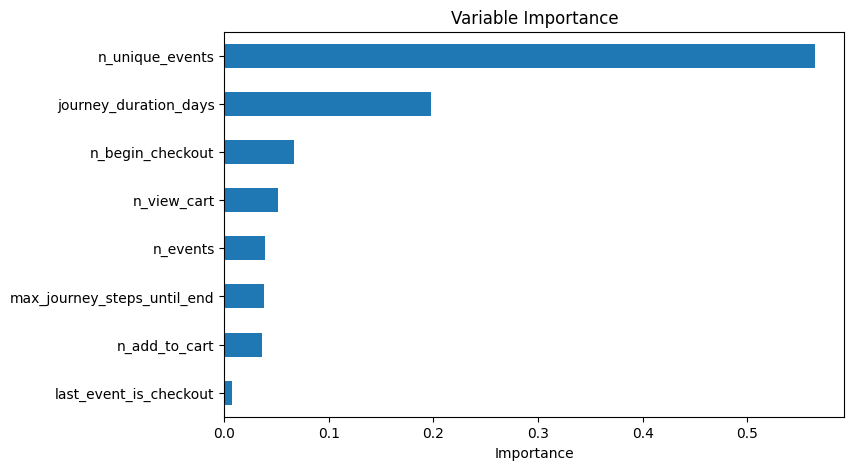

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Variable Importance')
plt.xlabel('Importance')
plt.show()


OOB accuracy: 0.9737917806496242
Training accuracy: 0.9998899474892305